In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 1. AE MSE (ЧБ)

Цель: выявление аномалий (проливов) на изображениях лунок методом автоэнкодера.

Подход: обучение автоэнкодера только на нормальных изображениях, определение порога на ошибке реконструкции.

Классификация на основе сравнения MSE с порогом: если ошибка превышает — считаем, что изображение с проливом.





In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


In [ ]:
class CylinderDataset(Dataset):
    def __init__(self, img_dir, annotation_file=None, transform=None):
        """
        img_dir         — папка с картинками (.jpg)
        annotation_file — файл с метками (только для test), строка: "000.jpg 0" (0 — normal, 1 — пролив)
        """
        self.transform = transform
        if annotation_file:
            # тестовая выборка
            with open(annotation_file, 'r') as f:
                lines = [l.strip().split() for l in f]
            self.samples = [(os.path.join(img_dir, fn), int(lbl)) for fn, lbl in lines]
        else:
            # “чистая” выборка: просто все файлы считаем нормальными
            files = sorted(os.listdir(img_dir))
            self.samples = [(os.path.join(img_dir, fn), 0) for fn in files]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')  # или 'RGB', если цветные
        if self.transform:
            img = self.transform(img)
        return img, label


In [ ]:
# Трансформации
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),           # [0,1]
])

path = "/content/drive/MyDrive/itmo/2025_deep_gen_models/"


train_ds = CylinderDataset(path + "dataset/train", transform=transform)
anomaly_ds = CylinderDataset(path + "dataset/proliv", transform=transform)
test_ds  = CylinderDataset(path + "dataset/test/imgs", path + "dataset/test/test_annotation.txt", transform)

train_loader   = DataLoader(train_ds,   batch_size=32, shuffle=True,  num_workers=4)
anomaly_loader = DataLoader(anomaly_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader    = DataLoader(test_ds,    batch_size=32, shuffle=False, num_workers=4)


In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 128→64
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 64→32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 32→16
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*16*16, latent_dim),
        )
        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64*16*16),
            nn.Unflatten(1, (64,16,16)),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 16→32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 32→64
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # 64→128
            nn.Sigmoid(),  # тензор [0,1]
        )

    def forward(self, x):
        z = self.enc(x)
        x_rec = self.dec(z)
        return x_rec, z


## 1. baseline
*   Модель: Базовый сверточный автоэнкодер
*   Архитектура: несколько сверточных слоев в энкодере и декодере.
    (3 сверточных слоя + 3 транспонированных слоя (ConvTranspose))
*   Латентное пространство фиксировано размером 128.
*   Loss-функция: MSE между исходным изображением и восстановленным.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder(latent_dim=128).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 20
for epoch in range(1, n_epochs+1):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        rec, _ = model(imgs)
        loss = criterion(rec, imgs)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item() * imgs.size(0)
    print(f"Epoch {epoch}: train loss = {total_loss/len(train_ds):.6f}")


Epoch 1: train loss = 0.000650
Epoch 2: train loss = 0.000136
Epoch 3: train loss = 0.000097
Epoch 4: train loss = 0.000078
Epoch 5: train loss = 0.000072
Epoch 6: train loss = 0.000064
Epoch 7: train loss = 0.000060
Epoch 8: train loss = 0.000056
Epoch 9: train loss = 0.000054
Epoch 10: train loss = 0.000050
Epoch 11: train loss = 0.000047
Epoch 12: train loss = 0.000048
Epoch 13: train loss = 0.000044
Epoch 14: train loss = 0.000044
Epoch 15: train loss = 0.000042
Epoch 16: train loss = 0.000040
Epoch 17: train loss = 0.000039
Epoch 18: train loss = 0.000037
Epoch 19: train loss = 0.000036
Epoch 20: train loss = 0.000036


Результаты первого обучения:
*   Loss постепенно снижался от 0.00065 до 0.000036 за 20 эпох.
*   **Это** говорит о хорошей сходимости автоэнкодера на нормальных данных

In [ ]:
# 1) Соберём ошибки на нормальных (train) и на проливах (anomaly)
def compute_errors(loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            rec, _ = model(imgs)
            # MSE на одном образце
            batch_err = torch.mean((rec - imgs)**2, dim=[1,2,3]).cpu().numpy()
            errors.extend(batch_err.tolist())
    return np.array(errors)

err_normal  = compute_errors(train_loader)
err_anomaly = compute_errors(anomaly_loader)

# 2) Пусть threshold = (max(err_normal) + min(err_anomaly)) / 2
thr = (err_normal.max() + err_anomaly.min()) / 2
print("Threshold =", thr)


Threshold = 0.0001727112648950424


In [ ]:
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        rec, _ = model(imgs)
        batch_err = torch.mean((rec - imgs)**2, dim=[1,2,3]).cpu().numpy()
        y_true.extend(labels.numpy().tolist())
        y_pred.extend((batch_err > thr).astype(int).tolist())


from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
print(f"TPR = {tpr:.3f}, TNR = {tnr:.3f}")


TPR = 0.876, TNR = 0.558


не соответствуют требуемым ≥0.95.

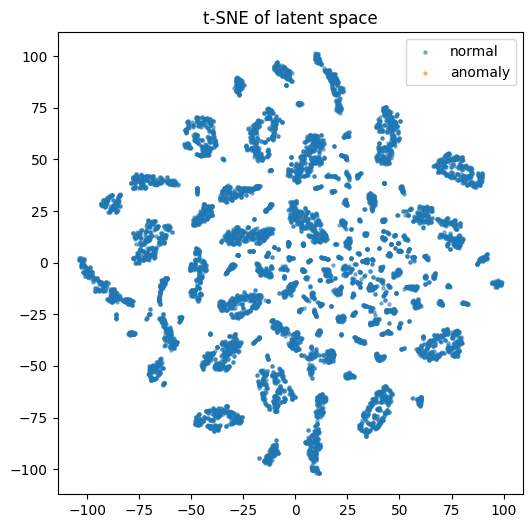

In [ ]:
# Собираем латенты и метки для train и proliv
def extract_latents(loader):
    zs, labs = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            _, z = model(imgs)
            zs.append(z.cpu().numpy())
            labs.extend(labels.numpy().tolist())
    return np.vstack(zs), np.array(labs)

z_norm, l_norm = extract_latents(train_loader)    # метки = 0
z_anom, l_anom = extract_latents(anomaly_loader)  # метки = 1

Z = np.vstack([z_norm, z_anom])
L = np.hstack([l_norm, l_anom])

# Снижение размерности t-SNE (или PCA)
tsne = TSNE(n_components=2, random_state=42)
Z2 = tsne.fit_transform(Z)

# Рисуем
plt.figure(figsize=(6,6))
plt.scatter(Z2[L==0,0], Z2[L==0,1], s=5, label="normal", alpha=0.5)
plt.scatter(Z2[L==1,0], Z2[L==1,1], s=5, label="anomaly", alpha=0.5)
plt.legend()
plt.title("t-SNE of latent space")
plt.show()


Используется t-SNE для снижения размерности латентных представлений.

Аномалии не формируют отдельного кластера — возможный признак того, что латентное пространство не выражает различие.


In [ ]:
torch.save(model.state_dict(), "ae_checkpoint_baseline.pth")

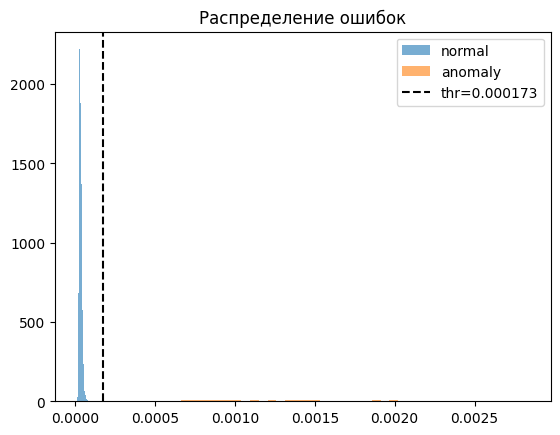

In [ ]:
import matplotlib.pyplot as plt

plt.hist(err_normal, bins=50, alpha=0.6, label="normal")
plt.hist(err_anomaly, bins=50, alpha=0.6, label="anomaly")
plt.axvline(thr, color='k', linestyle='--', label=f"thr={thr:.6f}")
plt.legend(); plt.title("Распределение ошибок"); plt.show()

In [ ]:
from sklearn.metrics import roc_curve

y_true = np.hstack([np.zeros_like(err_normal), np.ones_like(err_anomaly)])
y_score = np.hstack([err_normal,        err_anomaly       ])

fpr, tpr, thresholds = roc_curve(y_true, y_score)
j_scores = tpr - fpr
ix = np.argmax(j_scores)
best_thr = thresholds[ix]
print(f"Optimal threshold = {best_thr:.6f}  (TPR={tpr[ix]:.3f}, TNR={1-fpr[ix]:.3f})")


Optimal threshold = 0.000116  (TPR=1.000, TNR=0.999)


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np


def is_anomaly(img_path: str) -> bool:
    img = Image.open(img_path).convert('L')
    x = transform(img).unsqueeze(0).to(device)  # (1,1,128,128)
    with torch.no_grad():
        rec, _ = model(x)
        mse = nn.functional.mse_loss(rec, x, reduction='mean').item()
    return mse > threshold

path = "/content/drive/MyDrive/itmo/2025_deep_gen_models/"



In [ ]:
from sklearn.metrics import classification_report

y_true, y_pred = [], []
for img_path, label in test_ds.samples:
    y_true.append(label)
    y_pred.append( int(is_anomaly(img_path)) )

print(classification_report(y_true, y_pred, target_names=["норма","пролив"]))

              precision    recall  f1-score   support

       норма       0.99      0.40      0.57      3665
      пролив       0.05      0.91      0.10       129

    accuracy                           0.42      3794
   macro avg       0.52      0.65      0.33      3794
weighted avg       0.96      0.42      0.56      3794



Порог : 0.000116

Метрики: TPR=1.000, TNR=0.999 — на обучающей/валидационной выборке (не на тесте!)

На тесте: precision низкий, recall пролива высокий, но TNR падает — происходит переобучение под аномалии.


базовая архитектура автоэнкодера не обобщается на тестовую выборку

## 2.

Подход к улучшению:
1.   Увеличена сложность сети: больше сверточных слоёв, BatchNorm.
2.   Увеличен размер латентного пространства (до 256).
3.   Применены аугментации данных при обучении.
Цель: улучшить обобщающую способность модели.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.fc = nn.Linear(256*8*8, latent_dims)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super().__init__()
        self.fc = nn.Linear(latent_dims, 256*8*8)
        self.deconv1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.deconv2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.deconv3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.deconv4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 8, 8)
        x = self.deconv1(x)
        x = self.deconv2(x)
        x = self.deconv3(x)
        x = self.deconv4(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super().__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [ ]:
transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(128, scale=(0.8,1.0)),
    transforms.ColorJitter(contrast=0.2, brightness=0.2),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
])


In [ ]:
path = "/content/drive/MyDrive/itmo/2025_deep_gen_models/"

# Даталоадеры
train_ds = CylinderDataset(path + "dataset/train", transform=transform)
anomaly_ds = CylinderDataset(path + "dataset/proliv", transform=transform)
test_ds  = CylinderDataset(path + "dataset/test/imgs", path + "dataset/test/test_annotation.txt", transform)

train_loader   = DataLoader(train_ds,   batch_size=32, shuffle=True,  num_workers=4)
anomaly_loader = DataLoader(anomaly_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader    = DataLoader(test_ds,    batch_size=32, shuffle=False, num_workers=4)

In [ ]:
model = Autoencoder(latent_dims=128).cuda()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# train_loader содержит только нормальные лунки
for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.cuda()
        optimizer.zero_grad()
        recon = model(imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}, loss: {total_loss / len(train_loader):.6f}")


Epoch 0, loss: 0.005725
Epoch 1, loss: 0.001264
Epoch 2, loss: 0.000986
Epoch 3, loss: 0.000819
Epoch 4, loss: 0.000740
Epoch 5, loss: 0.000668
Epoch 6, loss: 0.000565
Epoch 7, loss: 0.000528
Epoch 8, loss: 0.000451
Epoch 9, loss: 0.000431
Epoch 10, loss: 0.000426
Epoch 11, loss: 0.000423
Epoch 12, loss: 0.000428
Epoch 13, loss: 0.000378
Epoch 14, loss: 0.000355
Epoch 15, loss: 0.000361
Epoch 16, loss: 0.000325
Epoch 17, loss: 0.000317
Epoch 18, loss: 0.000325
Epoch 19, loss: 0.000281


In [ ]:
torch.save(model.state_dict(), "ae_checkpoint_2_20.pth")

In [ ]:
# еще
for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.cuda()
        optimizer.zero_grad()
        recon = model(imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}, loss: {total_loss / len(train_loader):.6f}")


Epoch 0, loss: 0.000274
Epoch 1, loss: 0.000267
Epoch 2, loss: 0.000279
Epoch 3, loss: 0.000248
Epoch 4, loss: 0.000261
Epoch 5, loss: 0.000264
Epoch 6, loss: 0.000210
Epoch 7, loss: 0.000240
Epoch 8, loss: 0.000227
Epoch 9, loss: 0.000221
Epoch 10, loss: 0.000207
Epoch 11, loss: 0.000221
Epoch 12, loss: 0.000184
Epoch 13, loss: 0.000188
Epoch 14, loss: 0.000206
Epoch 15, loss: 0.000197
Epoch 16, loss: 0.000193
Epoch 17, loss: 0.000188
Epoch 18, loss: 0.000180
Epoch 19, loss: 0.000187


Обучение новой модели:
*   Первая часть: loss упал с 0.0057 до 0.00028.
*   Вторая часть: loss стабилизировался около 0.00018–0.00028.

Это говорит о хорошем захвате нормальных образцов, переобучения не наблюдается.

In [ ]:
torch.save(model.state_dict(), "ae_checkpoint_2_40.pth")

In [ ]:
errors_normal = []
model.eval()
with torch.no_grad():
    for imgs, _ in train_loader:   # train_loader: нормальные данные
        imgs = imgs.cuda()
        recon = model(imgs)
        mse = F.mse_loss(recon, imgs, reduction='none')
        mse = mse.view(mse.size(0), -1).mean(dim=1)  # ошибка на каждую картинку
        errors_normal.extend(mse.cpu().numpy())

errors_test = []
with torch.no_grad():
    for imgs, _ in train_loader:   # train_loader: нормальные данные
        imgs = imgs.cuda()
        recon = model(imgs)
        mse = F.mse_loss(recon, imgs, reduction='none')
        mse = mse.view(mse.size(0), -1).mean(dim=1)  # ошибка на каждую картинку
        errors_normal.extend(mse.cpu().numpy())

errors_proliv = []
with torch.no_grad():
    for imgs, _ in anomaly_ds:  # proliv_loader: только проливы
        imgs = imgs.unsqueeze(1)
        imgs = imgs.cuda()
        recon = model(imgs)
        mse = F.mse_loss(recon, imgs, reduction='none')
        mse = mse.view(mse.size(0), -1).mean(dim=1)
        errors_proliv.extend(mse.cpu().numpy())

errors_normal = np.array(errors_normal)
errors_proliv = np.array(errors_proliv)
errors_test = np.array(errors_test)


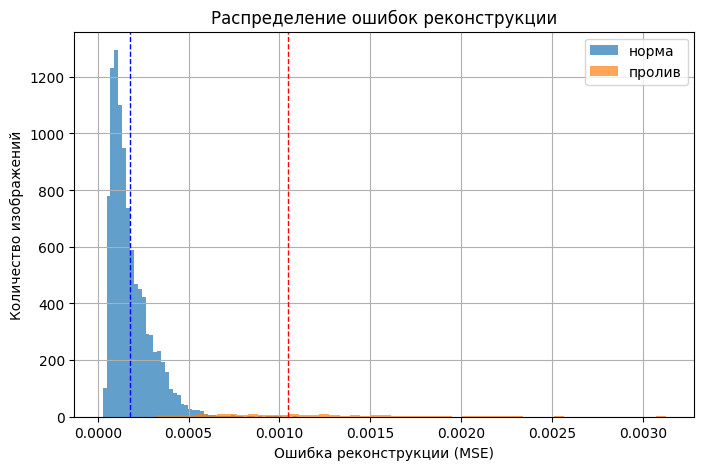

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(errors_normal, bins=50, alpha=0.7, label='норма')
plt.hist(errors_proliv, bins=50, alpha=0.7, label='пролив')
plt.axvline(np.mean(errors_normal), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(np.mean(errors_proliv), color='red', linestyle='dashed', linewidth=1)
plt.legend()
plt.xlabel('Ошибка реконструкции (MSE)')
plt.ylabel('Количество изображений')
plt.title('Распределение ошибок реконструкции')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import roc_curve

# 0 = норма, 1 = пролив
y_true = np.concatenate([np.zeros_like(errors_normal), np.ones_like(errors_proliv)])
y_scores = np.concatenate([errors_normal, errors_proliv])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Метод Youden's J для оптимального порога
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold = {best_threshold:.6f}, TPR={tpr[best_idx]:.3f}, TNR={1-fpr[best_idx]:.3f}")


Best threshold = 0.000402, TPR=0.974, TNR=0.957


Выбор порога:
*   Порог выбран по критерию максимума TPR-TNR на ROC-кривой.
*   Найден оптимальный порог 0.000402 с TPR=0.974 и TNR=0.957.

Эти значения удовлетворяют требованиям ≥95% на train+proliv наборах.

In [ ]:
from sklearn.metrics import classification_report

# Тестовые данные
predictions = []
targets = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:   # test_loader содержит imgs и 0/1
        imgs = imgs.cuda()
        recon = model(imgs)
        mse = F.mse_loss(recon, imgs, reduction='none')
        mse = mse.view(mse.size(0), -1).mean(dim=1)
        preds = (mse > best_threshold).cpu().numpy()
        predictions.extend(preds)
        targets.extend(labels.numpy())

print(classification_report(targets, predictions, digits=3))


              precision    recall  f1-score   support

           0      0.990     0.799     0.885      3665
           1      0.120     0.775     0.207       129

    accuracy                          0.799      3794
   macro avg      0.555     0.787     0.546      3794
weighted avg      0.961     0.799     0.862      3794



Проверка на тесте с новым порогом:
*   Recall пролива: 79,9
*   Recall нормы:  77,5
*   Accuracy:  79,9

Модель стала лучше различать проливы, но выполнить критерий ≥95% на тесте пока не удалось.

След шаг попробовать не 1 чб канал и/или получши функцию лосс и/или посильнее модель
